In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
data = pd.read_csv(r"results\Run_data.csv")
data.head()

,Unnamed: 0.1,Unnamed: 0,date,time,job_id,service_acc,circuit,mitigation,backend,S,a1b1c1d1e1f1g1h1,a2b2c1d2e1f1g1h1,a2b2c2d1e2f2g2h2,a1b1c2d2e2f2g2h2,Ideal S,Ideal_a1b1c1d1e1f1g1h1,Ideal_a2b2c1d2e1f1g1h1,Ideal_a2b2c2d1e2f2g2h2,Ideal_a1b1c2d2e2f2g2h2
0,0,0.0,19-01-2026,14:50:34,d5mvdmbh36vs73bilvc0,swapnil_charutarhealth,GHZ_UGC,no_mitigation,ibm_fez,2.983600,0.743200,-0.731200,0.748800,0.760400,4,1,-1,1,1
1,1,1.0,19-01-2026,14:51:22,d5mvdmbh36vs73bilvc0,swapnil_charutarhealth,GHZ_UGC,no_mitigation+m3,ibm_fez,3.380737,0.837984,-0.830932,0.848248,0.863573,4,1,-1,1,1
2,2,2.0,19-01-2026,17:33:47,d5n0bet9j2ac739lc5ug,swapnil_charutarhealth,GHZ_UGC,full_mitigation,ibm_marrakesh,2.980800,0.730200,-0.759000,0.740600,0.751000,4,1,-1,1,1
3,3,3.0,19-01-2026,17:57:52,d5n0bet9j2ac739lc5ug,swapnil_charutarhealth,GHZ_UGC,full_mitigation+m3,ibm_marrakesh,3.326079,0.807723,-0.844216,0.815455,0.858685,4,1,-1,1,1
4,4,4.0,19-01-2026,18:10:44,d5n0a1ph2mqc739bdl70,swapnil_charutarhealth,GHZ_DC,full_mitigation,ibm_fez,1.409400,0.345800,-0.355800,0.340800,0.367000,4,1,-1,1,1


In [41]:
mitigation_map = {
    "no_mitigation+m3": "M3 Only",
    "full_mitigation": "DD+Twirling(Gates + Measure)",
    "full_mitigation+m3": "DD+Twirling(Gates + Measure)+M3"
}

data["mitigation"] = data["mitigation"].replace(mitigation_map)

In [42]:
data_ugc = data[data["circuit"] == "GHZ_UGC"]
data_ugc

,Unnamed: 0.1,Unnamed: 0,date,time,job_id,service_acc,circuit,mitigation,backend,S,a1b1c1d1e1f1g1h1,a2b2c1d2e1f1g1h1,a2b2c2d1e2f2g2h2,a1b1c2d2e2f2g2h2,Ideal S,Ideal_a1b1c1d1e1f1g1h1,Ideal_a2b2c1d2e1f1g1h1,Ideal_a2b2c2d1e2f2g2h2,Ideal_a1b1c2d2e2f2g2h2
0,0,0.0,19-01-2026,14:50:34,d5mvdmbh36vs73bilvc0,swapnil_charutarhealth,GHZ_UGC,no_mitigation,ibm_fez,2.983600,0.743200,-0.731200,0.748800,0.760400,4,1,-1,1,1
1,1,1.0,19-01-2026,14:51:22,d5mvdmbh36vs73bilvc0,swapnil_charutarhealth,GHZ_UGC,M3 Only,ibm_fez,3.380737,0.837984,-0.830932,0.848248,0.863573,4,1,-1,1,1
2,2,2.0,19-01-2026,17:33:47,d5n0bet9j2ac739lc5ug,swapnil_charutarhealth,GHZ_UGC,DD+Twirling(Gates + Measure),ibm_marrakesh,2.980800,0.730200,-0.759000,0.740600,0.751000,4,1,-1,1,1
3,3,3.0,19-01-2026,17:57:52,d5n0bet9j2ac739lc5ug,swapnil_charutarhealth,GHZ_UGC,DD+Twirling(Gates + Measure)+M3,ibm_marrakesh,3.326079,0.807723,-0.844216,0.815455,0.858685,4,1,-1,1,1
6,6,6.0,19-01-2026,18:18:23,d5n08148d8hc73ch5bq0,swapnil_charutarhealth,GHZ_UGC,DD+Twirling(Gates + Measure),ibm_fez,2.857800,0.704200,-0.715000,0.730400,0.708200,4,1,-1,1,1
7,7,7.0,19-01-2026,18:21:16,d5n08148d8hc73ch5bq0,swapnil_charutarhealth,GHZ_UGC,DD+Twirling(Gates + Measure)+M3,ibm_fez,3.199712,0.787336,-0.801000,0.818673,0.792704,4,1,-1,1,1
10,10,10.0,19-01-2026,18:26:24,d5mvl5s8d8hc73ch4olg,swapnil_charutarhealth,GHZ_UGC,no_mitigation,ibm_marrakesh,2.827600,0.704600,-0.687800,0.726800,0.708400,4,1,-1,1,1
11,11,11.0,19-01-2026,18:31:50,d5mvl5s8d8hc73ch4olg,swapnil_charutarhealth,GHZ_UGC,M3 Only,ibm_marrakesh,3.209991,0.799880,-0.779976,0.825852,0.804283,4,1,-1,1,1
24,24,24.0,22-01-2026,15:58:58,d5ovlsc8d8hc73cjbvn0,tomisdaksh,GHZ_UGC,no_mitigation,ibm_marrakesh,3.278600,0.811400,-0.813600,0.828000,0.825600,4,1,-1,1,1
25,25,25.0,22-01-2026,16:02:37,d5ovlsc8d8hc73cjbvn0,tomisdaksh,GHZ_UGC,M3 Only,ibm_marrakesh,3.616279,0.895590,-0.897072,0.912088,0.911529,4,1,-1,1,1


In [43]:
data_ugs = data[data["circuit"] == "GHZ_UGS"]
data_ugs

,Unnamed: 0.1,Unnamed: 0,date,time,job_id,service_acc,circuit,mitigation,backend,S,a1b1c1d1e1f1g1h1,a2b2c1d2e1f1g1h1,a2b2c2d1e2f2g2h2,a1b1c2d2e2f2g2h2,Ideal S,Ideal_a1b1c1d1e1f1g1h1,Ideal_a2b2c1d2e1f1g1h1,Ideal_a2b2c2d1e2f2g2h2,Ideal_a1b1c2d2e2f2g2h2
16,16,16.0,21-01-2026,16:19:50,d5oauft9j2ac739msbfg,tomisdaksh,GHZ_UGS,no_mitigation,ibm_fez,2.601200,0.650600,-0.651400,0.648600,0.650600,4,1,-1,1,1
17,17,17.0,21-01-2026,16:20:02,d5oauft9j2ac739msbfg,tomisdaksh,GHZ_UGS,M3 Only,ibm_fez,2.944910,0.736816,-0.738148,0.733920,0.736026,4,1,-1,1,1
18,18,18.0,21-01-2026,16:24:31,d5oavi48d8hc73cimh30,tomisdaksh,GHZ_UGS,no_mitigation,ibm_marrakesh,1.752200,0.402600,-0.412400,0.456400,0.480800,4,1,-1,1,1
19,19,19.0,21-01-2026,16:28:32,d5oavi48d8hc73cimh30,tomisdaksh,GHZ_UGS,M3 Only,ibm_marrakesh,2.130591,0.490302,-0.500650,0.555356,0.584283,4,1,-1,1,1
20,20,20.0,21-01-2026,16:29:53,d5ob3659j2ac739msggg,tomisdaksh,GHZ_UGS,DD+Twirling(Gates + Measure),ibm_fez,2.461600,0.609800,-0.605000,0.622400,0.624400,4,1,-1,1,1
21,21,21.0,21-01-2026,16:30:06,d5ob3659j2ac739msggg,tomisdaksh,GHZ_UGS,DD+Twirling(Gates + Measure)+M3,ibm_fez,2.790104,0.690631,-0.685937,0.705223,0.708312,4,1,-1,1,1
22,22,22.0,21-01-2026,16:34:23,d5ob3tk8d8hc73cimlog,tomisdaksh,GHZ_UGS,DD+Twirling(Gates + Measure),ibm_marrakesh,1.650200,0.369200,-0.380200,0.449400,0.451400,4,1,-1,1,1
23,23,23.0,21-01-2026,16:38:29,d5ob3tk8d8hc73cimlog,tomisdaksh,GHZ_UGS,DD+Twirling(Gates + Measure)+M3,ibm_marrakesh,2.049131,0.459854,-0.471589,0.557956,0.559732,4,1,-1,1,1
30,30,30.0,23-01-2026,12:06:02,d5phdh9dgvjs73dbp1f0,tomisdaksh,GHZ_UGS,no_mitigation,ibm_fez,2.497200,0.598800,-0.617200,0.643200,0.638000,4,1,-1,1,1
31,31,31.0,23-01-2026,12:06:20,d5phdh9dgvjs73dbp1f0,tomisdaksh,GHZ_UGS,M3 Only,ibm_fez,3.007337,0.721084,-0.743497,0.774803,0.767954,4,1,-1,1,1


In [44]:
len(data_ugs)

28

In [45]:
required_cols = [
    "backend",
    "mitigation",
    "S",
    "a1b1c1d1e1f1g1h1",
    "a2b2c1d2e1f1g1h1",
    "a2b2c2d1e2f2g2h2",
    "a1b1c2d2e2f2g2h2"
]

avg_df_ugc = (
    data_ugc[required_cols]
    .groupby(["backend", "mitigation"], as_index=False)
    .mean()
)

avg_df_ugs = (
    data_ugs[required_cols]
    .groupby(["backend", "mitigation"], as_index=False)
    .mean()
)

In [46]:
avg_df_ugc

,backend,mitigation,S,a1b1c1d1e1f1g1h1,a2b2c1d2e1f1g1h1,a2b2c2d1e2f2g2h2,a1b1c2d2e2f2g2h2
0,ibm_fez,DD+Twirling(Gates + Measure),2.192467,0.550600,-0.547533,0.554733,0.539600
1,ibm_fez,DD+Twirling(Gates + Measure)+M3,2.762209,0.695096,-0.689750,0.698387,0.678975
2,ibm_fez,M3 Only,3.206751,0.798894,-0.793674,0.807183,0.807000
3,ibm_fez,no_mitigation,2.496933,0.622600,-0.617067,0.629333,0.627933
4,ibm_marrakesh,DD+Twirling(Gates + Measure),3.056100,0.762500,-0.766450,0.762650,0.764500
5,ibm_marrakesh,DD+Twirling(Gates + Measure)+M3,3.414248,0.850393,-0.855779,0.849343,0.858732
6,ibm_marrakesh,M3 Only,3.532935,0.875048,-0.877021,0.891952,0.888914
7,ibm_marrakesh,no_mitigation,3.145450,0.779050,-0.781100,0.794150,0.791150


In [47]:
avg_df_ugs

,backend,mitigation,S,a1b1c1d1e1f1g1h1,a2b2c1d2e1f1g1h1,a2b2c2d1e2f2g2h2,a1b1c2d2e2f2g2h2
0,ibm_fez,DD+Twirling(Gates + Measure),1.930800,0.463100,-0.475750,0.483250,0.508700
1,ibm_fez,DD+Twirling(Gates + Measure)+M3,2.320440,0.554660,-0.573230,0.579028,0.613523
2,ibm_fez,M3 Only,2.807480,0.698735,-0.686096,0.702797,0.719851
3,ibm_fez,no_mitigation,2.302200,0.573300,-0.562400,0.577050,0.589450
4,ibm_marrakesh,DD+Twirling(Gates + Measure),2.018267,0.488667,-0.478733,0.524533,0.526333
5,ibm_marrakesh,DD+Twirling(Gates + Measure)+M3,2.374320,0.574817,-0.561844,0.617555,0.620104
6,ibm_marrakesh,M3 Only,2.590275,0.635261,-0.627709,0.653536,0.673770
7,ibm_marrakesh,no_mitigation,2.214000,0.543467,-0.537067,0.558200,0.575267


In [48]:
operators = [
    'a1b1c1d1e1f1g1h1',
    'a2b2c1d2e1f1g1h1',
    'a2b2c2d1e2f2g2h2',
    'a1b1c2d2e2f2g2h2'
]

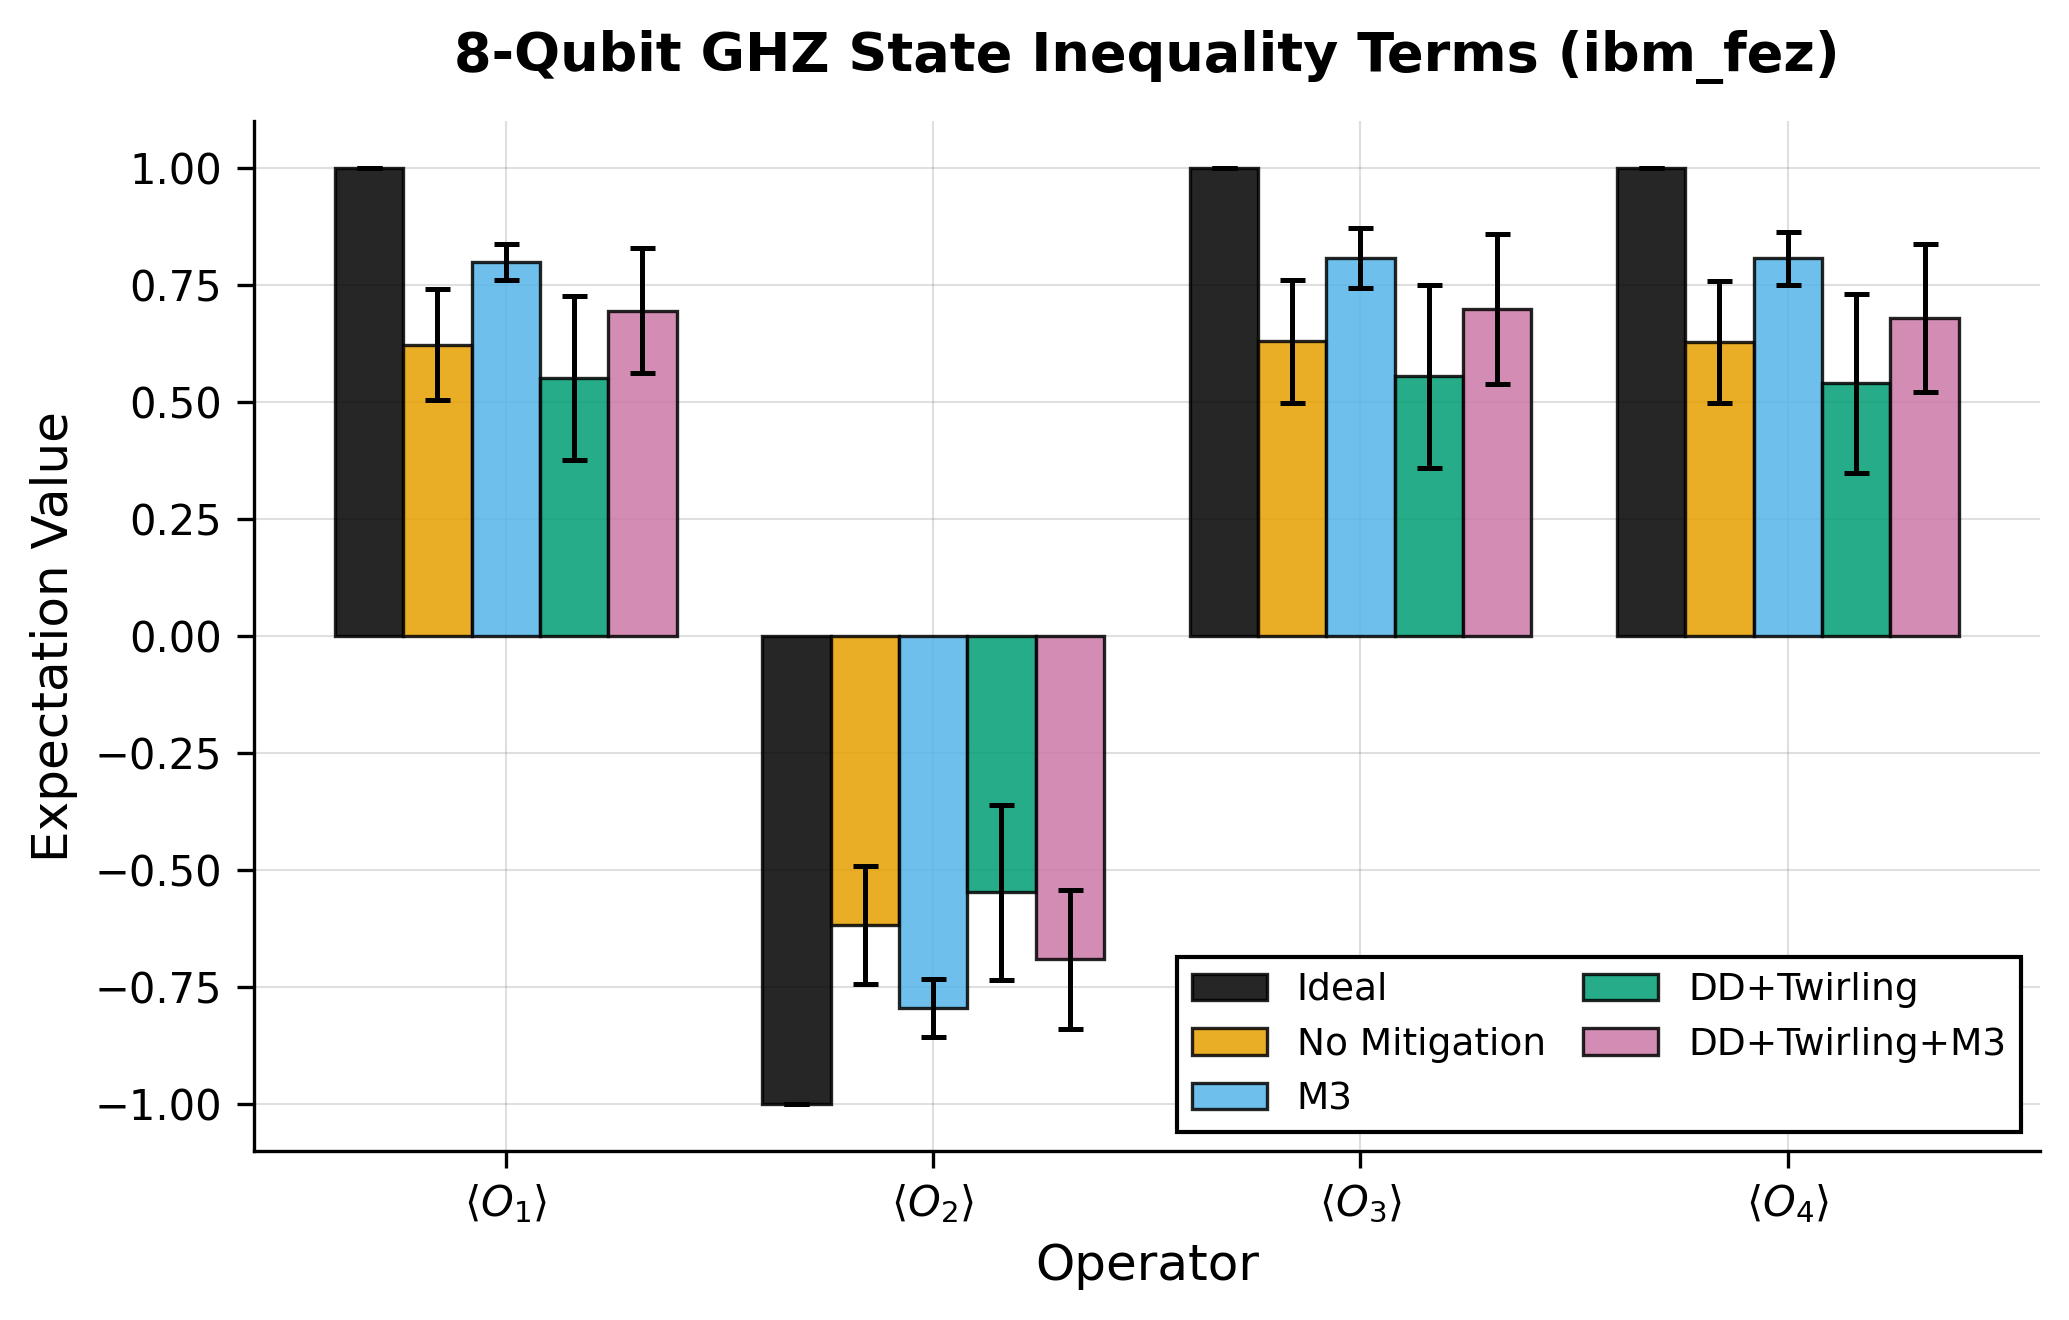

In [51]:
backend_name = "ibm_fez"

operators = [
    'a1b1c1d1e1f1g1h1',
    'a2b2c1d2e1f1g1h1',
    'a2b2c2d1e2f2g2h2',
    'a1b1c2d2e2f2g2h2'
]

ideal_operators = [
    'Ideal_a1b1c1d1e1f1g1h1',
    'Ideal_a2b2c1d2e1f1g1h1',
    'Ideal_a2b2c2d1e2f2g2h2',
    'Ideal_a1b1c2d2e2f2g2h2'
]

mitigations = [
    "Ideal",
    "no_mitigation",
    "M3 Only",
    "DD+Twirling(Gates + Measure)",
    "DD+Twirling(Gates + Measure)+M3"
]

# Use cleaner labels for publication
mitigation_labels = {
    "Ideal": "Ideal",
    "no_mitigation": "No Mitigation",
    "M3 Only": "M3",
    "DD+Twirling(Gates + Measure)": "DD+Twirling",
    "DD+Twirling(Gates + Measure)+M3": "DD+Twirling+M3"
}

# Shorter operator labels
operator_labels = [
    r'$\langle O_1 \rangle$',
    r'$\langle O_2 \rangle$',
    r'$\langle O_3 \rangle$',
    r'$\langle O_4 \rangle$'
]

x = np.arange(len(operators))
width = 0.16

# Professional color scheme (colorblind-friendly)
colors = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#CC79A7']

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

for i, mit in enumerate(mitigations):

    if mit == "Ideal":
        means = [data_ugc[col].mean() for col in ideal_operators]
        errs  = [data_ugc[col].std()  for col in ideal_operators]
        label = mitigation_labels[mit]
    else:
        subset = data_ugc[
            (data_ugc["backend"] == backend_name) &
            (data_ugc["mitigation"] == mit)
        ]
        means = [subset[op].mean() for op in operators]
        errs  = [subset[op].std()  for op in operators]
        label = mitigation_labels[mit]

    ax.bar(
        x + (i - 2) * width,
        means,
        width,
        yerr=errs,
        capsize=3,
        label=label,
        color=colors[i],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85,
        error_kw={'linewidth': 1.2, 'elinewidth': 1.2, 'capthick': 1.2}
    )

# --------------------------------------------------
# Formatting for publication
# --------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(operator_labels, fontsize=11)
ax.set_ylabel("Expectation Value", fontsize=12, fontweight='normal')
ax.set_xlabel("Operator", fontsize=12, fontweight='normal')
ax.set_title(f"8-Qubit GHZ State Inequality Terms ({backend_name})", 
             fontsize=13, fontweight='bold', pad=12)

# Grid styling - behind bars, subtle
ax.set_axisbelow(True)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='gray', axis='both')
ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.3, color='gray', axis='x', which='minor')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Legend
ax.legend(frameon=True, fancybox=False, shadow=False, 
          ncol=2, loc='best', fontsize=9,
          framealpha=1, edgecolor='black', 
          columnspacing=1.0, handlelength=2)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=10, 
               direction='out', length=4, width=0.8)

plt.tight_layout()
plt.savefig(f'8qghz_state_inequality_{backend_name}_ugc.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

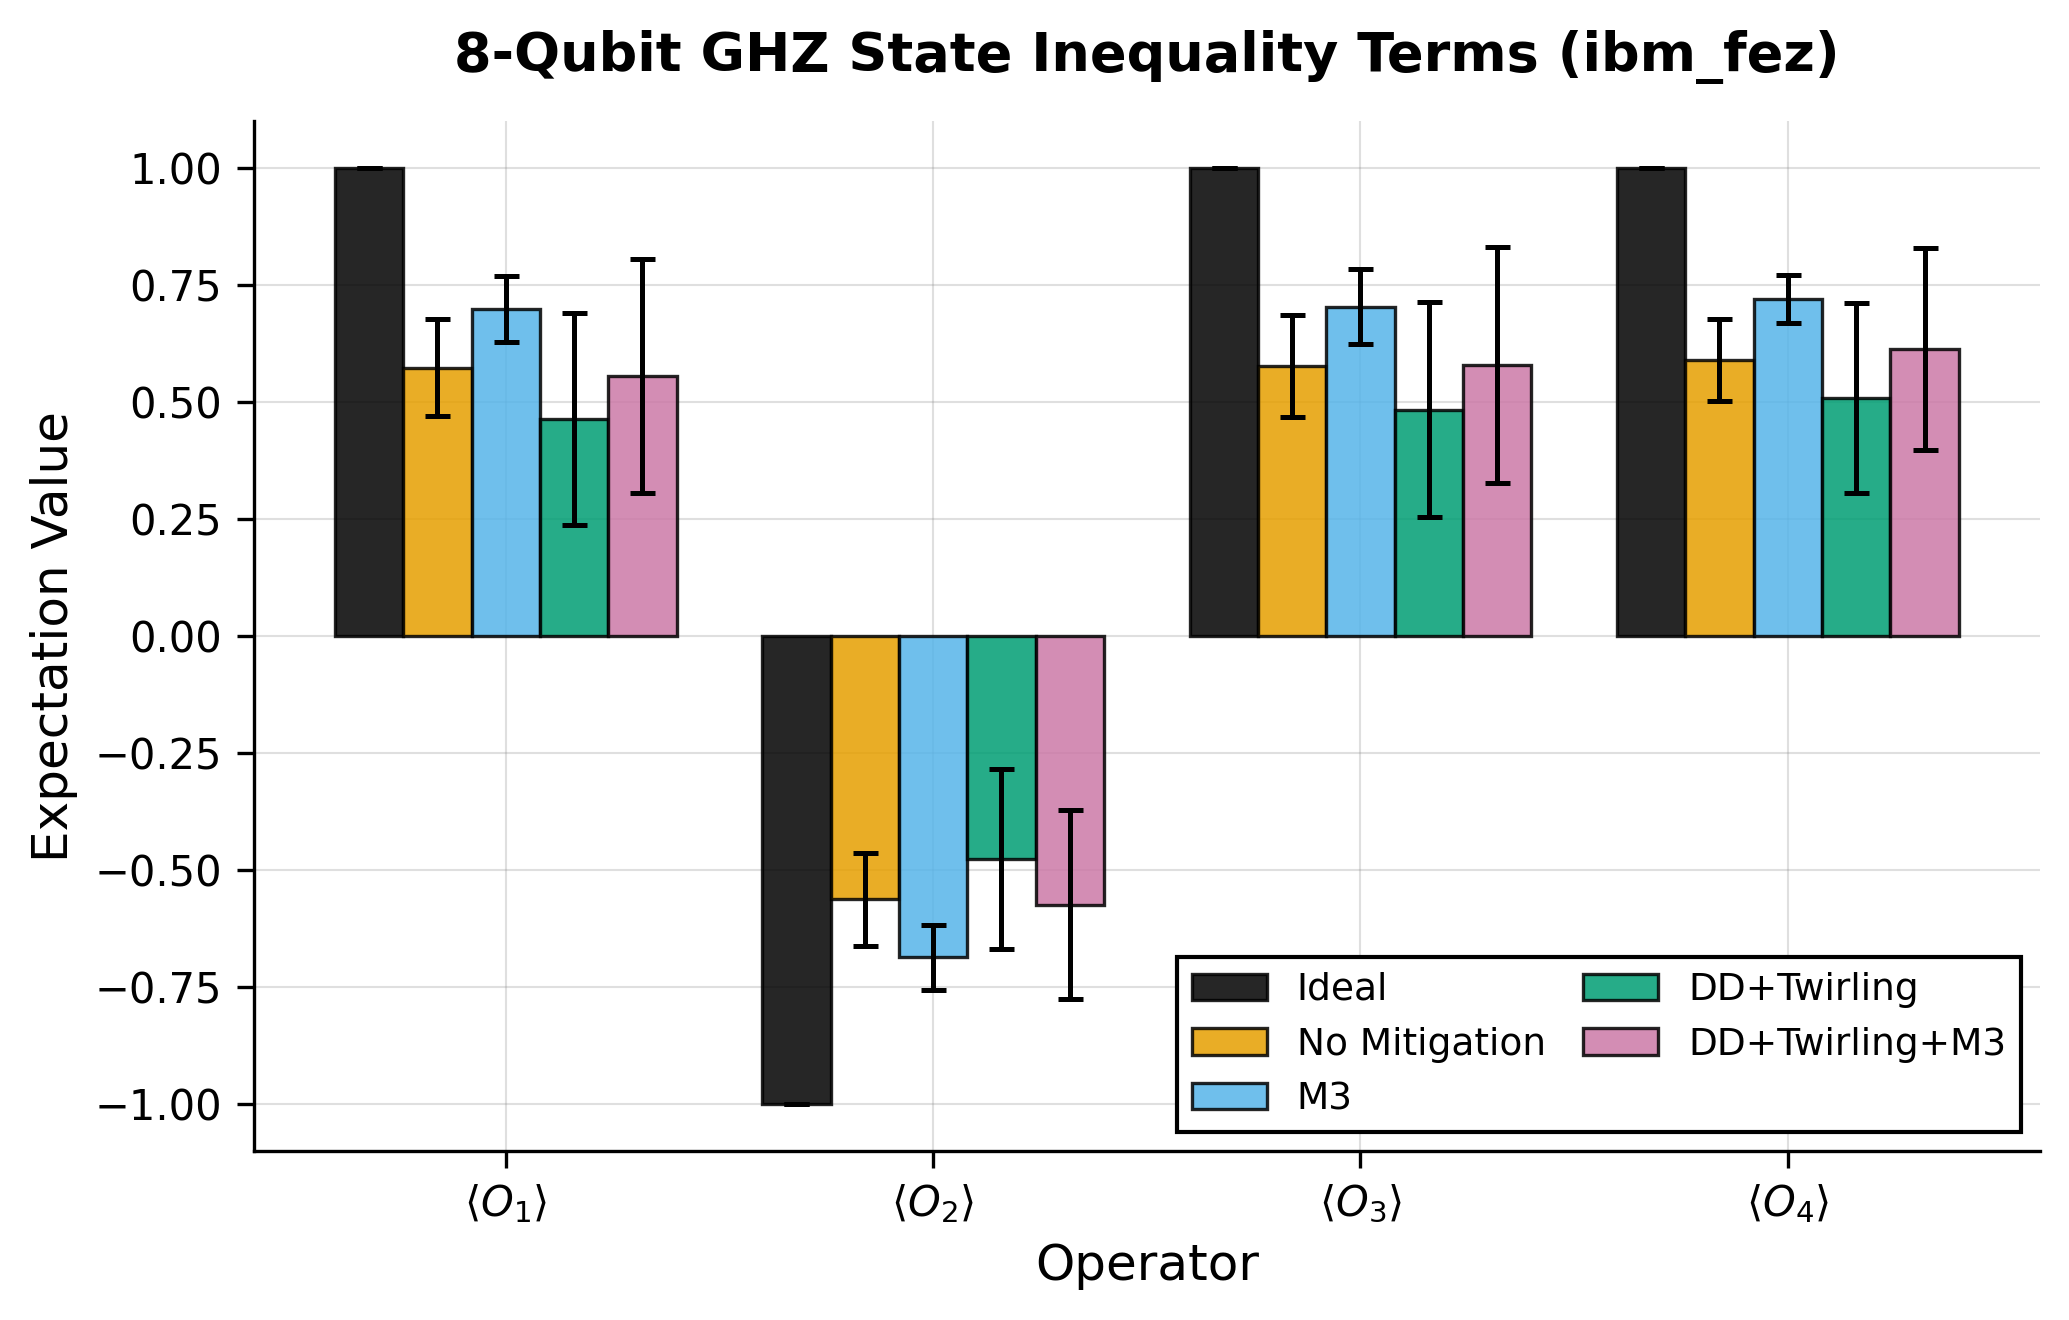

In [52]:
backend_name = "ibm_fez"

operators = [
    'a1b1c1d1e1f1g1h1',
    'a2b2c1d2e1f1g1h1',
    'a2b2c2d1e2f2g2h2',
    'a1b1c2d2e2f2g2h2'
]

ideal_operators = [
    'Ideal_a1b1c1d1e1f1g1h1',
    'Ideal_a2b2c1d2e1f1g1h1',
    'Ideal_a2b2c2d1e2f2g2h2',
    'Ideal_a1b1c2d2e2f2g2h2'
]

mitigations = [
    "Ideal",
    "no_mitigation",
    "M3 Only",
    "DD+Twirling(Gates + Measure)",
    "DD+Twirling(Gates + Measure)+M3"
]

# Use cleaner labels for publication
mitigation_labels = {
    "Ideal": "Ideal",
    "no_mitigation": "No Mitigation",
    "M3 Only": "M3",
    "DD+Twirling(Gates + Measure)": "DD+Twirling",
    "DD+Twirling(Gates + Measure)+M3": "DD+Twirling+M3"
}

# Shorter operator labels
operator_labels = [
    r'$\langle O_1 \rangle$',
    r'$\langle O_2 \rangle$',
    r'$\langle O_3 \rangle$',
    r'$\langle O_4 \rangle$'
]

x = np.arange(len(operators))
width = 0.16

# Professional color scheme (colorblind-friendly)
colors = ['#000000', '#E69F00', '#56B4E9', '#009E73', '#CC79A7']

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

for i, mit in enumerate(mitigations):

    if mit == "Ideal":
        means = [data_ugs[col].mean() for col in ideal_operators]
        errs  = [data_ugs[col].std()  for col in ideal_operators]
        label = mitigation_labels[mit]
    else:
        subset = data_ugs[
            (data_ugs["backend"] == backend_name) &
            (data_ugs["mitigation"] == mit)
        ]
        means = [subset[op].mean() for op in operators]
        errs  = [subset[op].std()  for op in operators]
        label = mitigation_labels[mit]

    ax.bar(
        x + (i - 2) * width,
        means,
        width,
        yerr=errs,
        capsize=3,
        label=label,
        color=colors[i],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85,
        error_kw={'linewidth': 1.2, 'elinewidth': 1.2, 'capthick': 1.2}
    )

# --------------------------------------------------
# Formatting for publication
# --------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(operator_labels, fontsize=11)
ax.set_ylabel("Expectation Value", fontsize=12, fontweight='normal')
ax.set_xlabel("Operator", fontsize=12, fontweight='normal')
ax.set_title(f"8-Qubit GHZ State Inequality Terms ({backend_name})", 
             fontsize=13, fontweight='bold', pad=12)

# Grid styling - behind bars, subtle
ax.set_axisbelow(True)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='gray', axis='both')
ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.3, color='gray', axis='x', which='minor')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Legend
ax.legend(frameon=True, fancybox=False, shadow=False, 
          ncol=2, loc='best', fontsize=9,
          framealpha=1, edgecolor='black', 
          columnspacing=1.0, handlelength=2)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=10, 
               direction='out', length=4, width=0.8)

plt.tight_layout()
plt.savefig(f'8qghz_state_inequality_{backend_name}_ugs.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

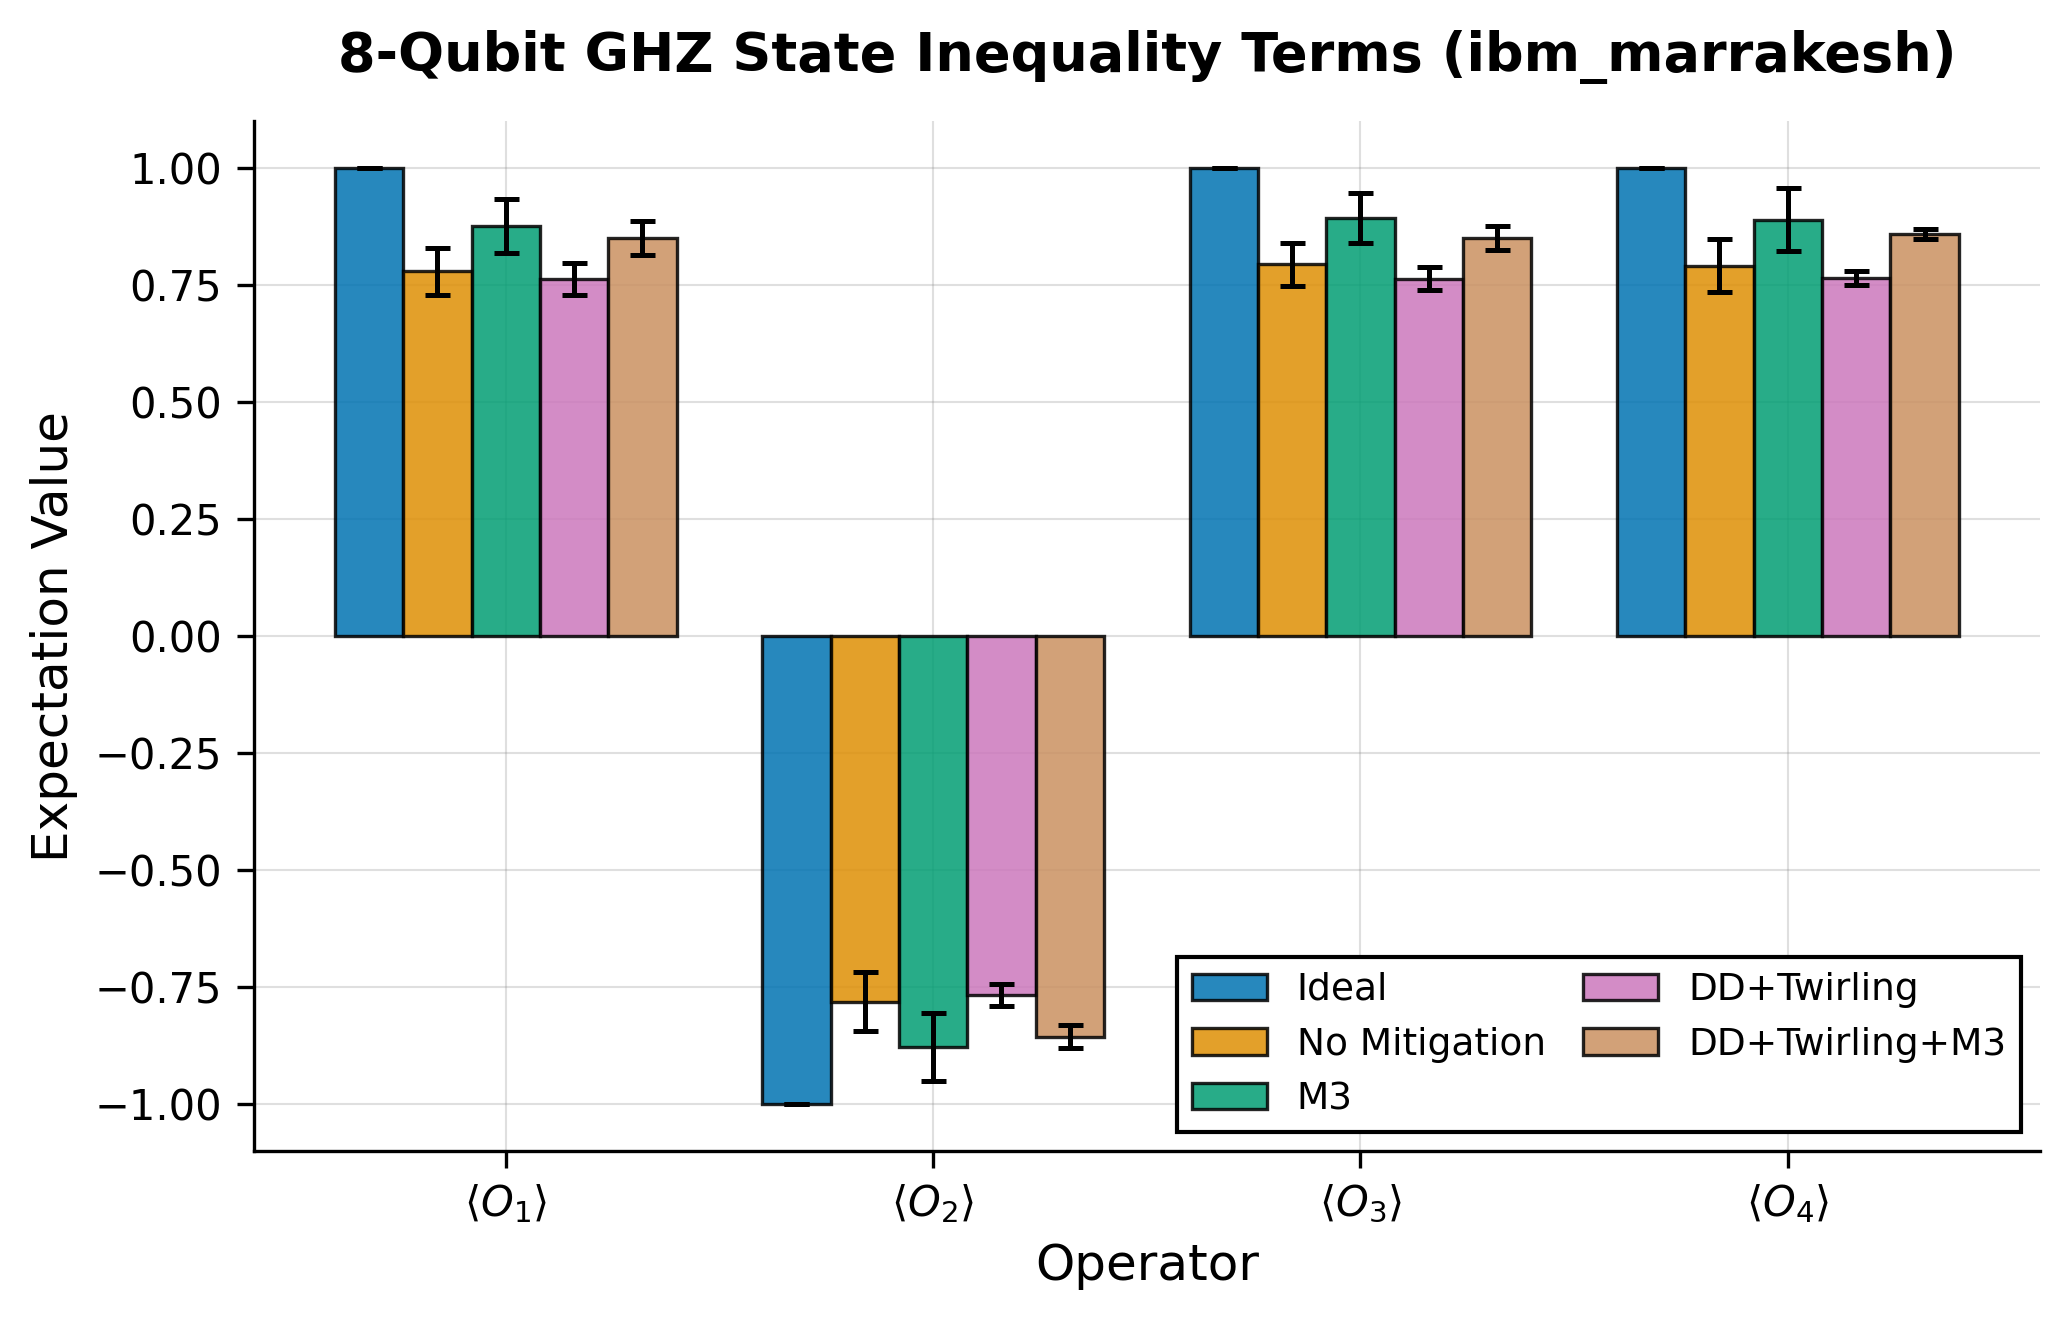

In [53]:
backend_name = "ibm_marrakesh"

operators = [
    'a1b1c1d1e1f1g1h1',
    'a2b2c1d2e1f1g1h1',
    'a2b2c2d1e2f2g2h2',
    'a1b1c2d2e2f2g2h2'
]

ideal_operators = [
    'Ideal_a1b1c1d1e1f1g1h1',
    'Ideal_a2b2c1d2e1f1g1h1',
    'Ideal_a2b2c2d1e2f2g2h2',
    'Ideal_a1b1c2d2e2f2g2h2'
]

mitigations = [
    "Ideal",
    "no_mitigation",
    "M3 Only",
    "DD+Twirling(Gates + Measure)",
    "DD+Twirling(Gates + Measure)+M3"
]

# Use cleaner labels for publication
mitigation_labels = {
    "Ideal": "Ideal",
    "no_mitigation": "No Mitigation",
    "M3 Only": "M3",
    "DD+Twirling(Gates + Measure)": "DD+Twirling",
    "DD+Twirling(Gates + Measure)+M3": "DD+Twirling+M3"
}

# Shorter operator labels
operator_labels = [
    r'$\langle O_1 \rangle$',
    r'$\langle O_2 \rangle$',
    r'$\langle O_3 \rangle$',
    r'$\langle O_4 \rangle$'
]

x = np.arange(len(operators))
width = 0.16

# Professional color scheme (colorblind-friendly)
colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161']

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

for i, mit in enumerate(mitigations):

    if mit == "Ideal":
        means = [data_ugc[col].mean() for col in ideal_operators]
        errs  = [data_ugc[col].std()  for col in ideal_operators]
        label = mitigation_labels[mit]
    else:
        subset = data_ugc[
            (data_ugc["backend"] == backend_name) &
            (data_ugc["mitigation"] == mit)
        ]
        means = [subset[op].mean() for op in operators]
        errs  = [subset[op].std()  for op in operators]
        label = mitigation_labels[mit]

    ax.bar(
        x + (i - 2) * width,
        means,
        width,
        yerr=errs,
        capsize=3,
        label=label,
        color=colors[i],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85,
        error_kw={'linewidth': 1.2, 'elinewidth': 1.2, 'capthick': 1.2}
    )

# --------------------------------------------------
# Formatting for publication
# --------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(operator_labels, fontsize=11)
ax.set_ylabel("Expectation Value", fontsize=12, fontweight='normal')
ax.set_xlabel("Operator", fontsize=12, fontweight='normal')
ax.set_title(f"8-Qubit GHZ State Inequality Terms ({backend_name})", 
             fontsize=13, fontweight='bold', pad=12)

# Grid styling - behind bars, subtle
ax.set_axisbelow(True)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='gray', axis='both')
ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.3, color='gray', axis='x', which='minor')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Legend
ax.legend(frameon=True, fancybox=False, shadow=False, 
          ncol=2, loc='best', fontsize=9,
          framealpha=1, edgecolor='black', 
          columnspacing=1.0, handlelength=2)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=10, 
               direction='out', length=4, width=0.8)

plt.tight_layout()
plt.savefig(f'8qghz_state_inequality_{backend_name}_ugc.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

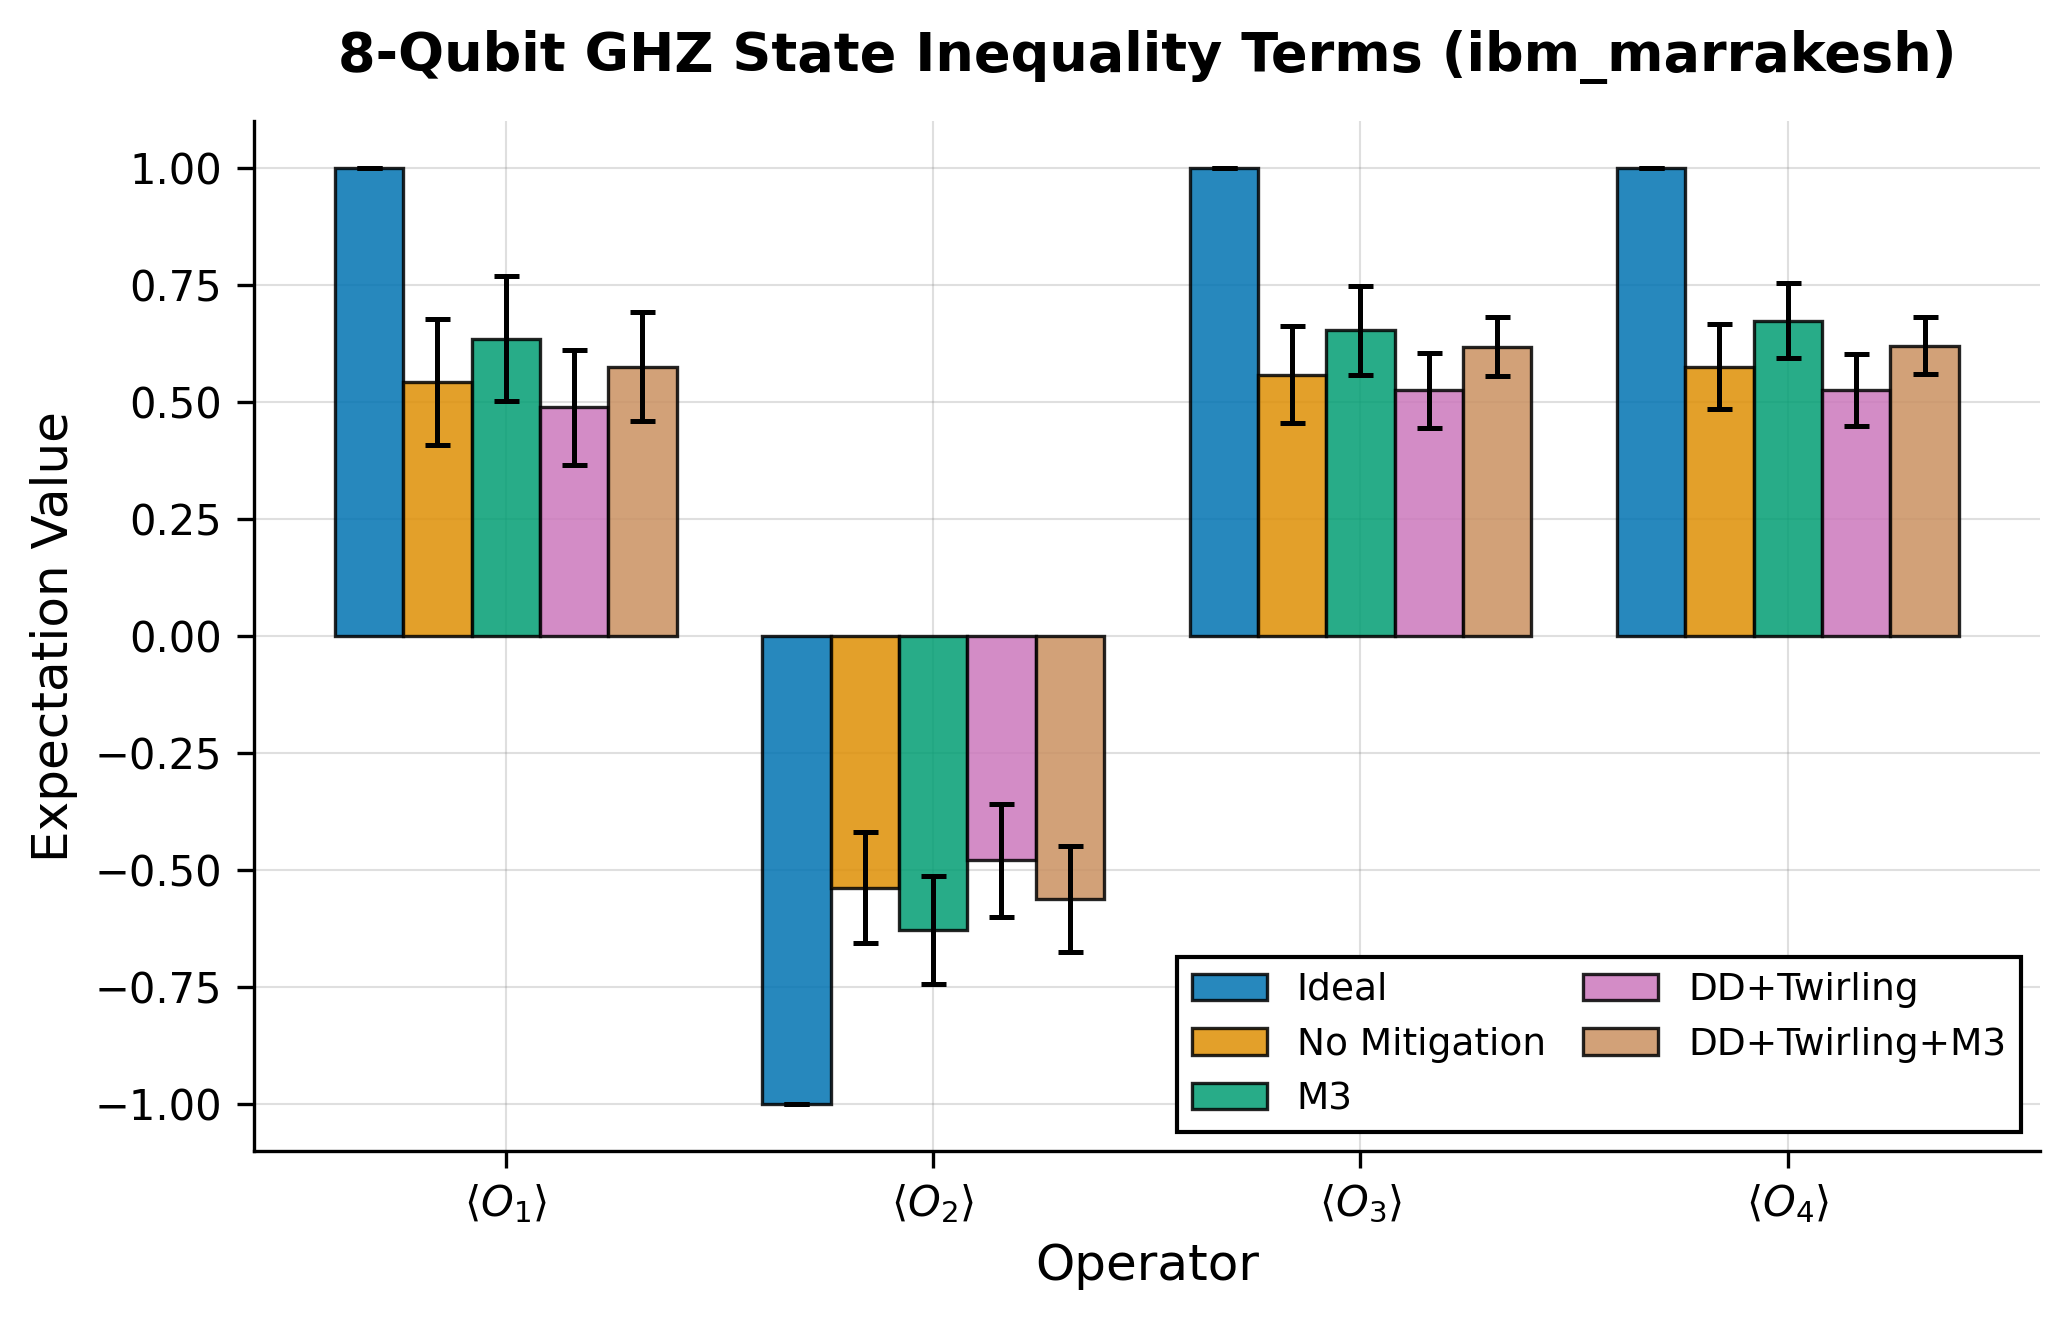

In [54]:
backend_name = "ibm_marrakesh"

operators = [
    'a1b1c1d1e1f1g1h1',
    'a2b2c1d2e1f1g1h1',
    'a2b2c2d1e2f2g2h2',
    'a1b1c2d2e2f2g2h2'
]

ideal_operators = [
    'Ideal_a1b1c1d1e1f1g1h1',
    'Ideal_a2b2c1d2e1f1g1h1',
    'Ideal_a2b2c2d1e2f2g2h2',
    'Ideal_a1b1c2d2e2f2g2h2'
]

mitigations = [
    "Ideal",
    "no_mitigation",
    "M3 Only",
    "DD+Twirling(Gates + Measure)",
    "DD+Twirling(Gates + Measure)+M3"
]

# Use cleaner labels for publication
mitigation_labels = {
    "Ideal": "Ideal",
    "no_mitigation": "No Mitigation",
    "M3 Only": "M3",
    "DD+Twirling(Gates + Measure)": "DD+Twirling",
    "DD+Twirling(Gates + Measure)+M3": "DD+Twirling+M3"
}

# Shorter operator labels
operator_labels = [
    r'$\langle O_1 \rangle$',
    r'$\langle O_2 \rangle$',
    r'$\langle O_3 \rangle$',
    r'$\langle O_4 \rangle$'
]

x = np.arange(len(operators))
width = 0.16

# Professional color scheme (colorblind-friendly)
colors = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161']

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

for i, mit in enumerate(mitigations):

    if mit == "Ideal":
        means = [data_ugs[col].mean() for col in ideal_operators]
        errs  = [data_ugs[col].std()  for col in ideal_operators]
        label = mitigation_labels[mit]
    else:
        subset = data_ugs[
            (data_ugs["backend"] == backend_name) &
            (data_ugs["mitigation"] == mit)
        ]
        means = [subset[op].mean() for op in operators]
        errs  = [subset[op].std()  for op in operators]
        label = mitigation_labels[mit]

    ax.bar(
        x + (i - 2) * width,
        means,
        width,
        yerr=errs,
        capsize=3,
        label=label,
        color=colors[i],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85,
        error_kw={'linewidth': 1.2, 'elinewidth': 1.2, 'capthick': 1.2}
    )

# --------------------------------------------------
# Formatting for publication
# --------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(operator_labels, fontsize=11)
ax.set_ylabel("Expectation Value", fontsize=12, fontweight='normal')
ax.set_xlabel("Operator", fontsize=12, fontweight='normal')
ax.set_title(f"8-Qubit GHZ State Inequality Terms ({backend_name})", 
             fontsize=13, fontweight='bold', pad=12)

# Grid styling - behind bars, subtle
ax.set_axisbelow(True)
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='gray', axis='both')
ax.grid(True, alpha=0.15, linestyle='-', linewidth=0.3, color='gray', axis='x', which='minor')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Legend
ax.legend(frameon=True, fancybox=False, shadow=False, 
          ncol=2, loc='best', fontsize=9,
          framealpha=1, edgecolor='black', 
          columnspacing=1.0, handlelength=2)

# Tick parameters
ax.tick_params(axis='both', which='major', labelsize=10, 
               direction='out', length=4, width=0.8)

plt.tight_layout()
plt.savefig(f'8qghz_state_inequality_{backend_name}_ugs.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

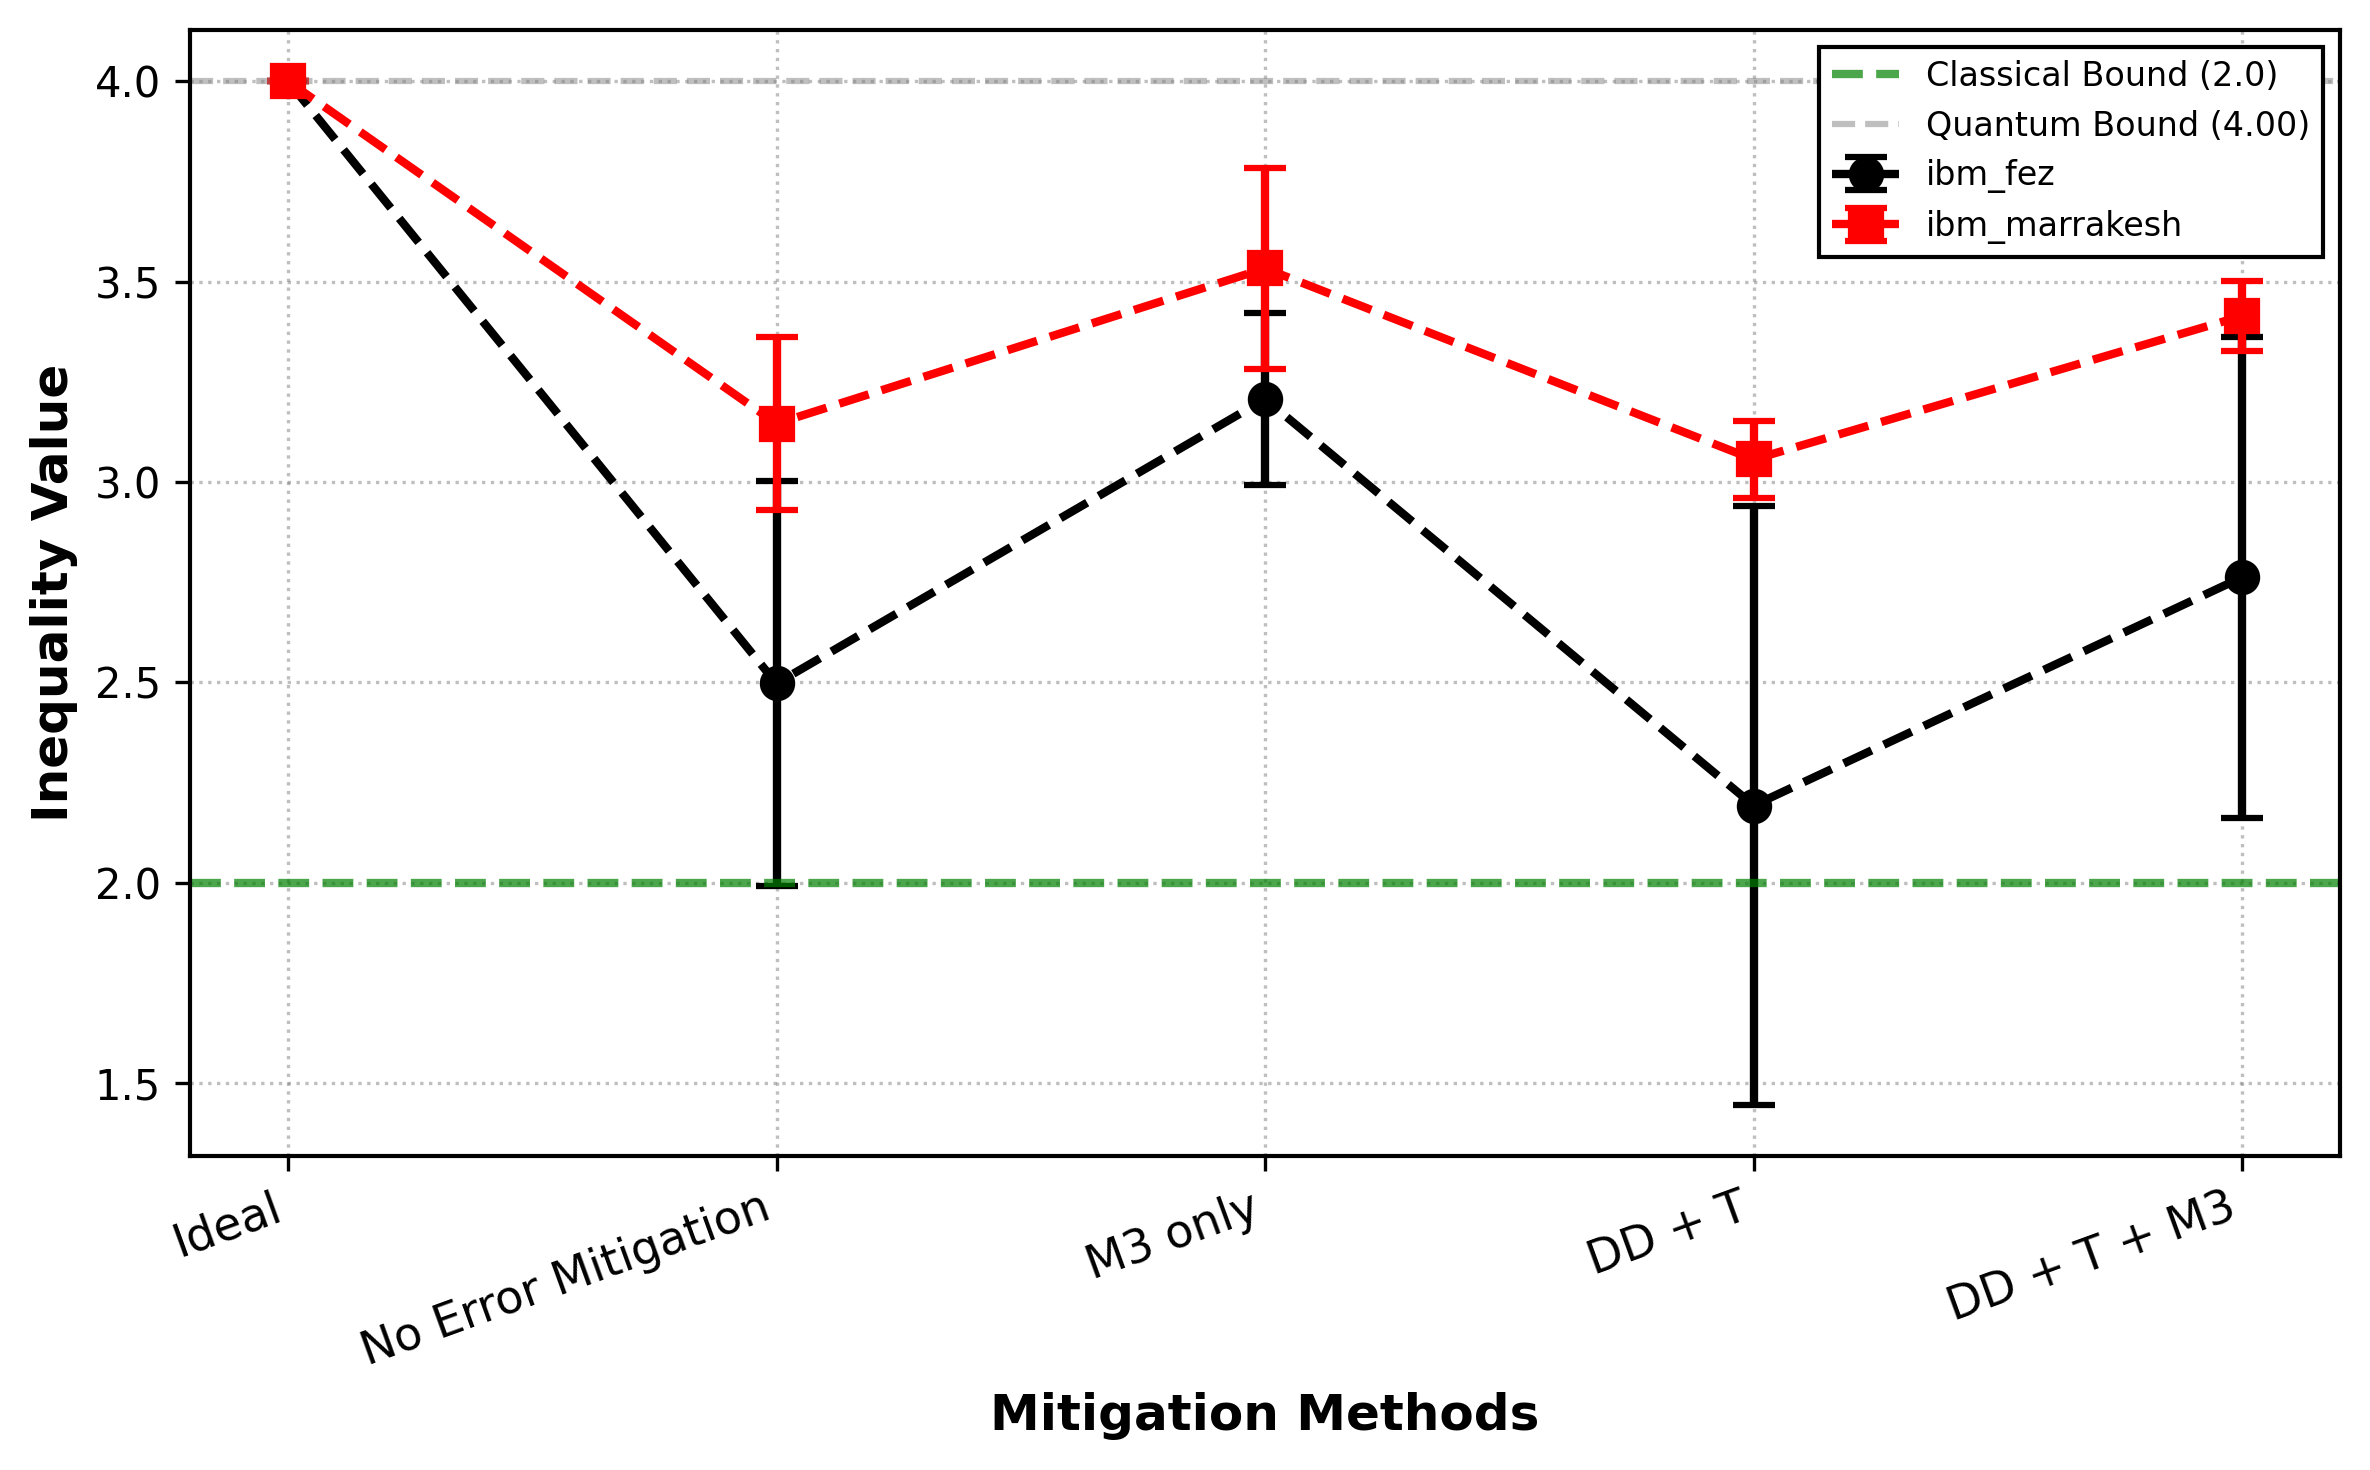

In [71]:
backends = ["ibm_fez", "ibm_marrakesh"]

mitigations = [
    "no_mitigation",
    "M3 Only",
    "DD+Twirling(Gates + Measure)",
    "DD+Twirling(Gates + Measure)+M3"
]

# Use cleaner labels matching the reference figure
mitigation_labels = {
    "no_mitigation": "No Error Mitigation",
    "M3 Only": "M3 only",
    "DD+Twirling(Gates + Measure)": "DD + T",
    "DD+Twirling(Gates + Measure)+M3": "DD + T + M3"
}

# Create x positions - starting from 1 to leave space for Ideal
x = np.arange(len(mitigations)) + 1  # Start at position 1

def get_mean_std(df, backend):
    mean = []
    std = []
    for m in mitigations:
        sub = df[(df["mitigation"] == m) & (df["backend"] == backend)]
        mean.append(sub["S"].mean())
        std.append(sub["S"].std())
    return np.array(mean), np.array(std)

# Get ideal value (backend-independent)
ideal_value = data_ugc["Ideal S"][0]

# Colors and markers for backends
colors = ['black', 'red']
markers = ['o', 's']

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

for i, backend in enumerate(backends):
    mean, std = get_mean_std(data_ugc, backend)
    
    # Add ideal point to the beginning
    full_mean = np.concatenate([[ideal_value], mean])
    full_std = np.concatenate([[0], std])
    full_x = np.concatenate([[0], x])
    
    ax.errorbar(
        full_x, full_mean, yerr=full_std,
        fmt=markers[i] + '--', capsize=5, linewidth=2,
        markersize=7, markeredgewidth=1.5, markerfacecolor=colors[i],
        markeredgecolor=colors[i],
        label=backend,
        color=colors[i],
        elinewidth=2, capthick=2
    )

# Classical bound (green dashed)
ax.axhline(2.0, color='green', linestyle='--', linewidth=2, alpha=0.7, 
           label='Classical Bound (2.0)')

# Ideal/Quantum bound (black dashed)
ax.axhline(ideal_value, color='gray', linestyle='--', linewidth=1.5, alpha=0.5,
           label=f'Quantum Bound ({ideal_value:.2f})')

# --------------------------------------------------
# Formatting
# --------------------------------------------------
all_labels = ['Ideal'] + [mitigation_labels[m] for m in mitigations]
all_positions = [0] + list(x)

ax.set_xticks(all_positions)
ax.set_xticklabels(all_labels, fontsize=11, rotation=20, ha='right')
ax.set_ylabel("Inequality Value", fontsize=12, fontweight='bold')
ax.set_xlabel("Mitigation Methods", fontsize=12, fontweight='bold')

# Set y-axis range
# ax.set_ylim(1.4, 4.1)

# Grid - darker and behind
ax.set_axisbelow(True)
ax.grid(True, alpha=0.5, linestyle=':', linewidth=0.8, color='gray', axis='both')

# All spines visible
for spine in ax.spines.values():
    spine.set_linewidth(1)

# Legend - smaller
ax.legend(frameon=True, fontsize=8, loc='upper right', edgecolor='black', 
          framealpha=1, fancybox=False)

plt.tight_layout()
plt.savefig('inequality_violation_ugc.png', dpi=300, bbox_inches='tight')
plt.show()

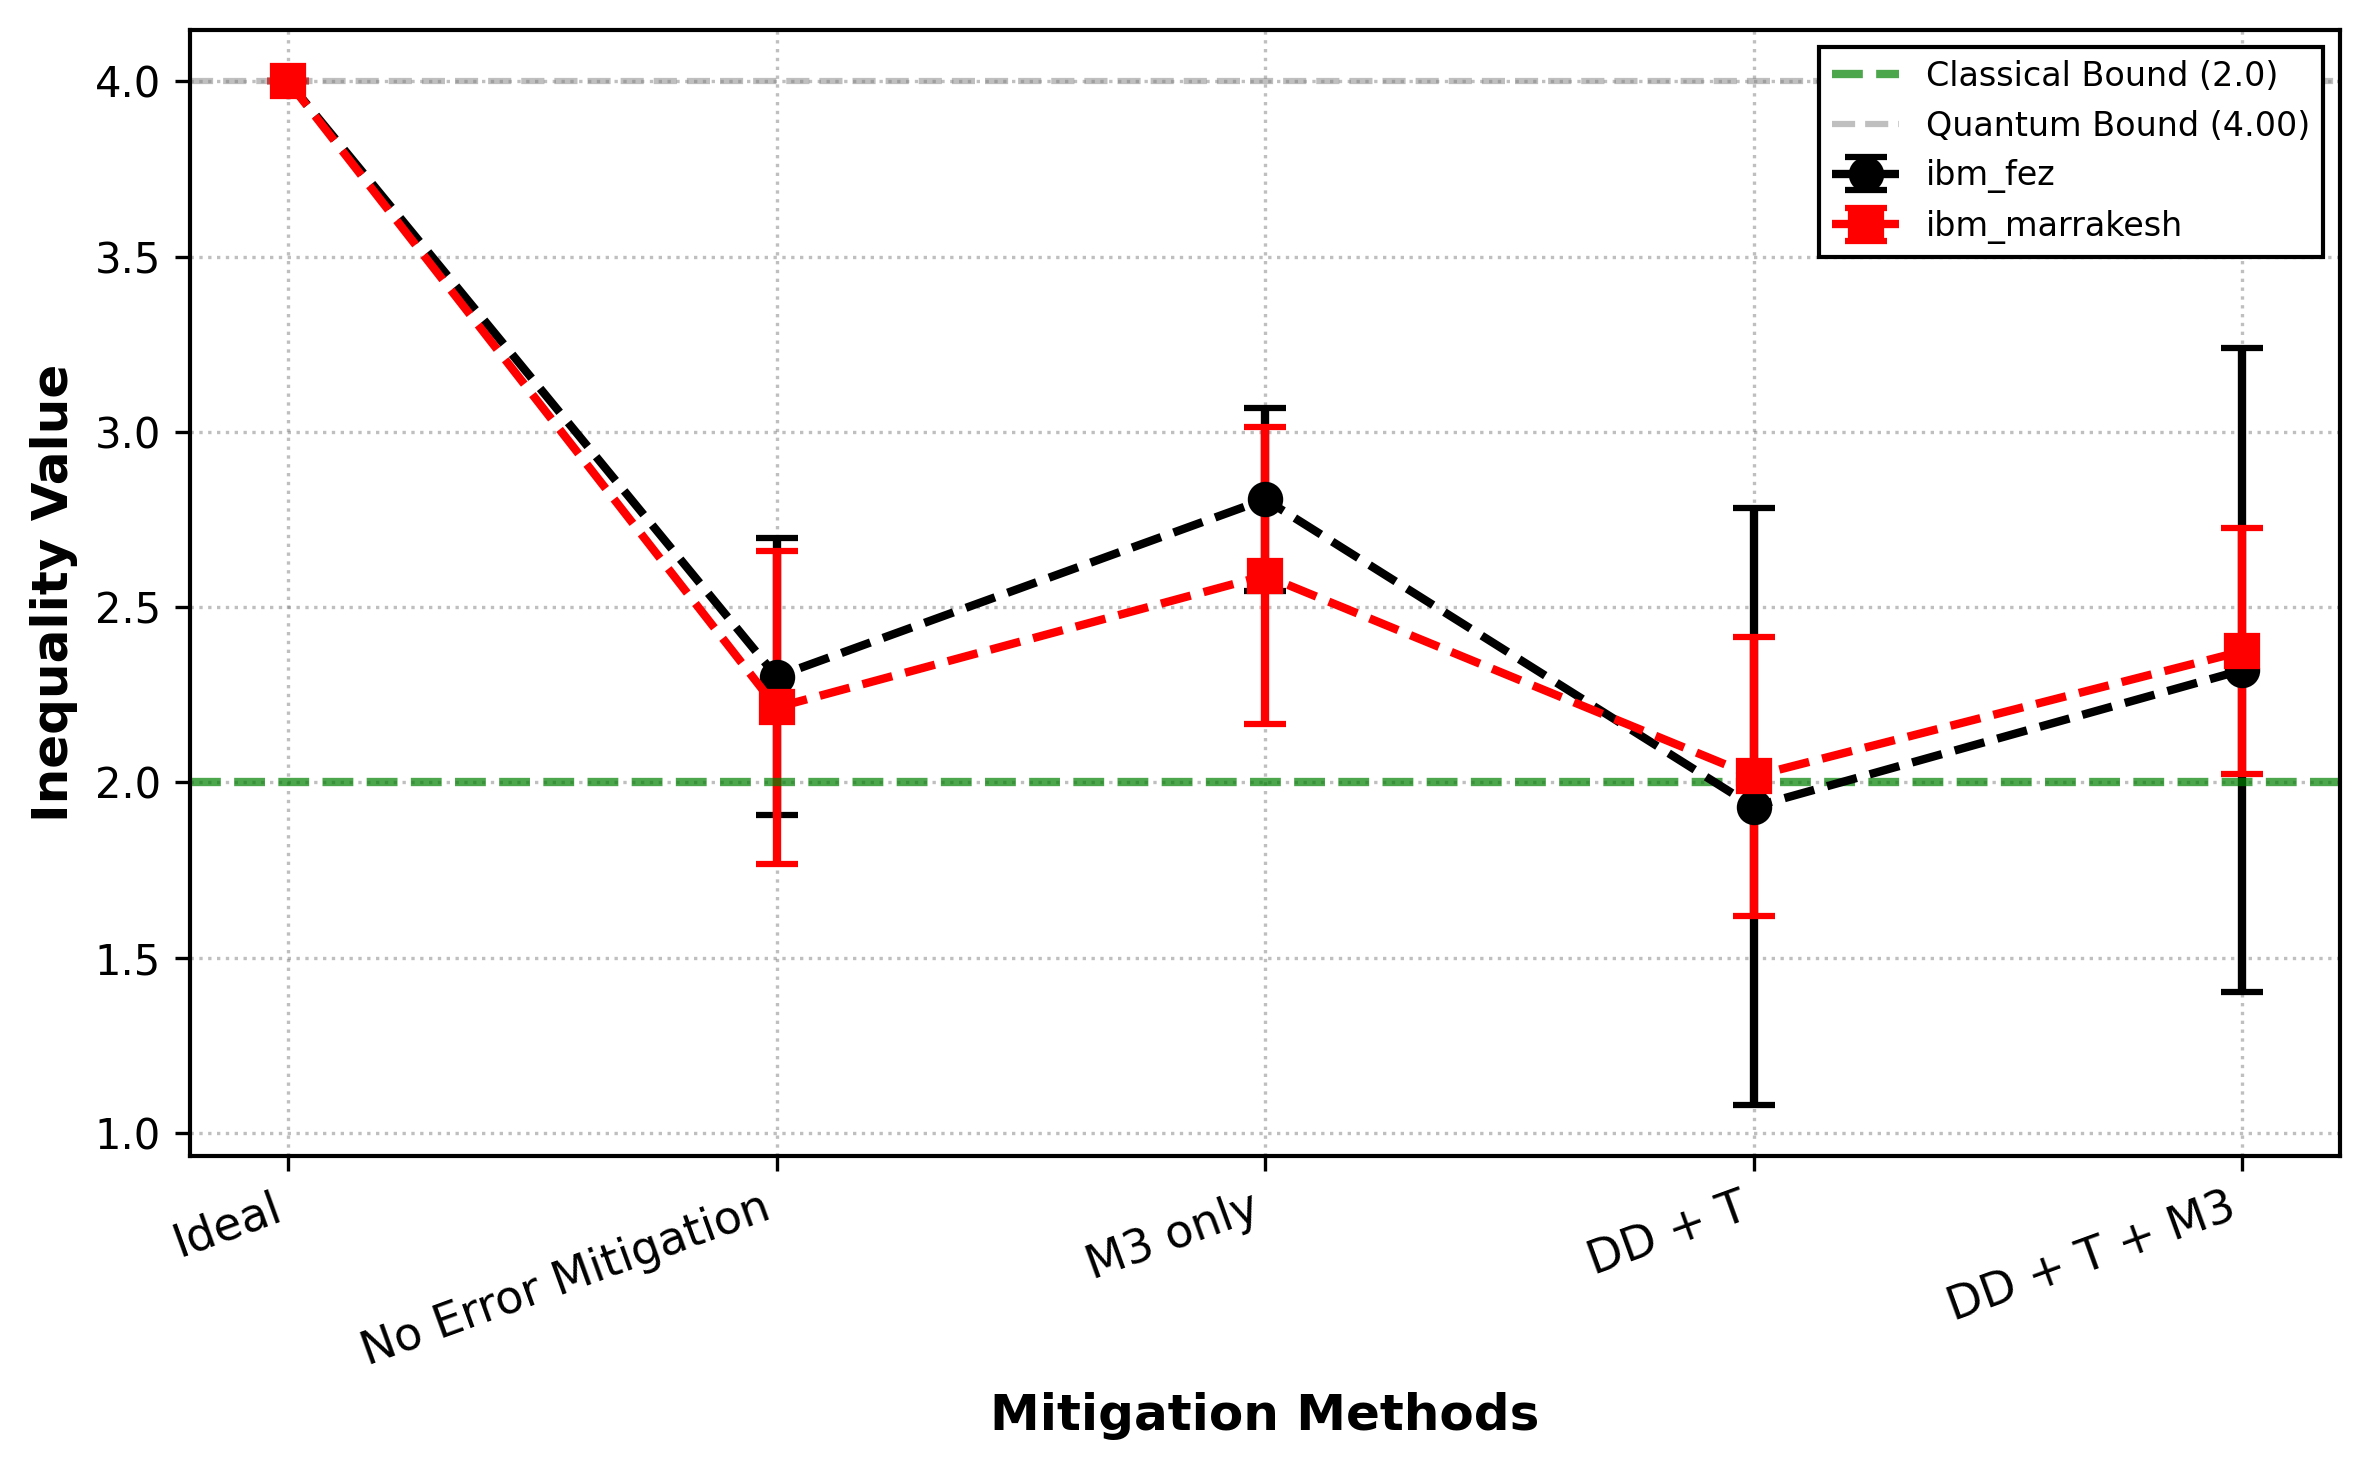

In [70]:
backends = ["ibm_fez", "ibm_marrakesh"]

mitigations = [
    "no_mitigation",
    "M3 Only",
    "DD+Twirling(Gates + Measure)",
    "DD+Twirling(Gates + Measure)+M3"
]

# Use cleaner labels matching the reference figure
mitigation_labels = {
    "no_mitigation": "No Error Mitigation",
    "M3 Only": "M3 only",
    "DD+Twirling(Gates + Measure)": "DD + T",
    "DD+Twirling(Gates + Measure)+M3": "DD + T + M3"
}

# Create x positions - starting from 1 to leave space for Ideal
x = np.arange(len(mitigations)) + 1  # Start at position 1

def get_mean_std(df, backend):
    mean = []
    std = []
    for m in mitigations:
        sub = df[(df["mitigation"] == m) & (df["backend"] == backend)]
        mean.append(sub["S"].mean())
        std.append(sub["S"].std())
    return np.array(mean), np.array(std)

# Get ideal value (backend-independent)
ideal_value = data_ugs["Ideal S"][16]

# Colors and markers for backends
colors = ['black', 'red']
markers = ['o', 's']

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

for i, backend in enumerate(backends):
    mean, std = get_mean_std(data_ugs, backend)
    
    # Add ideal point to the beginning
    full_mean = np.concatenate([[ideal_value], mean])
    full_std = np.concatenate([[0], std])
    full_x = np.concatenate([[0], x])
    
    ax.errorbar(
        full_x, full_mean, yerr=full_std,
        fmt=markers[i] + '--', capsize=5, linewidth=2,
        markersize=7, markeredgewidth=1.5, markerfacecolor=colors[i],
        markeredgecolor=colors[i],
        label=backend,
        color=colors[i],
        elinewidth=2, capthick=2
    )

# Classical bound (green dashed)
ax.axhline(2.0, color='green', linestyle='--', linewidth=2, alpha=0.7, 
           label='Classical Bound (2.0)')

# Ideal/Quantum bound (black dashed)
ax.axhline(ideal_value, color='gray', linestyle='--', linewidth=1.5, alpha=0.5,
           label=f'Quantum Bound ({ideal_value:.2f})')

# --------------------------------------------------
# Formatting
# --------------------------------------------------
all_labels = ['Ideal'] + [mitigation_labels[m] for m in mitigations]
all_positions = [0] + list(x)

ax.set_xticks(all_positions)
ax.set_xticklabels(all_labels, fontsize=11, rotation=20, ha='right')
ax.set_ylabel("Inequality Value", fontsize=12, fontweight='bold')
ax.set_xlabel("Mitigation Methods", fontsize=12, fontweight='bold')

# Set y-axis range
# ax.set_ylim(1.4, 4.1)

# Grid - darker and behind
ax.set_axisbelow(True)
ax.grid(True, alpha=0.5, linestyle=':', linewidth=0.8, color='gray', axis='both')

# All spines visible
for spine in ax.spines.values():
    spine.set_linewidth(1)

# Legend - smaller
ax.legend(frameon=True, fontsize=8, loc='upper right', edgecolor='black', 
          framealpha=1, fancybox=False)

plt.tight_layout()
plt.savefig('inequality_violation_ugs.png', dpi=300, bbox_inches='tight')
plt.show()